# MCCFR (External Sampling) — Convergence & Comparison

This notebook trains **External Sampling MCCFR** and compares it against **Vanilla CFR** on Kuhn and Leduc Poker, then tests MCCFR on Limit Hold'em.

External sampling enumerates all actions for the traversing player and samples a single action for the opponent, giving lower variance per iteration than outcome sampling with no importance weights needed.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
from itertools import permutations
from src.algorithms.cfr import CFR
from src.algorithms.mccfr import MCCFR
from src.training.kuhn_poker import KuhnPokerRules
from src.training.leduc_poker import LeducPokerRules
from src.training.limit_poker import LimitPokerRules

## Exploitability Computation

Reused from the vanilla CFR notebook — exact enumeration for Kuhn/Leduc, MC sampling for Limit.

In [2]:
def _get_all_deals(game):
    if isinstance(game, KuhnPokerRules):
        return list(permutations([0, 1, 2], 2))
    elif isinstance(game, LeducPokerRules):
        return list(permutations([0, 1, 2, 3, 4, 5], 3))
    raise ValueError("Unknown game type — use compute_exploitability_sampled for large games")


def _node_info(game, cards, history):
    player = game.get_acting_player(history)
    player_card = cards[player]
    flop = cards[2] if len(cards) > 2 else None
    return player, player_card, (flop, None, None)


def _traverse_br(game, opp_strategy, br_pure, br_player, cards, history, opp_reach, cf_values):
    player, player_card, com_cards = _node_info(game, cards, history)

    if game.is_terminal(history):
        sign = 1 if br_player == 0 else -1
        return opp_reach * sign * game.get_payoff(cards[:2], history, com_cards)

    actions = game.get_legal_actions(history)
    info_set_key = game.get_info_set_string(player_card, history, com_cards)

    if player == br_player:
        if info_set_key not in cf_values:
            cf_values[info_set_key] = [0.0] * len(actions)

        action_vals = []
        for i, action in enumerate(actions):
            val = _traverse_br(game, opp_strategy, br_pure, br_player, cards,
                               history + action, opp_reach, cf_values)
            cf_values[info_set_key][i] += val
            action_vals.append(val)

        if info_set_key in br_pure:
            return action_vals[br_pure[info_set_key]]
        return max(action_vals)
    else:
        strat = opp_strategy.get(info_set_key, [1.0 / len(actions)] * len(actions))
        ev = 0.0
        for i, action in enumerate(actions):
            ev += _traverse_br(game, opp_strategy, br_pure, br_player, cards,
                               history + action, opp_reach * strat[i], cf_values)
        return ev


def _eval_br(game, opp_strategy, br_pure, br_player, cards, history, opp_reach):
    player, player_card, com_cards = _node_info(game, cards, history)

    if game.is_terminal(history):
        sign = 1 if br_player == 0 else -1
        return opp_reach * sign * game.get_payoff(cards[:2], history, com_cards)

    actions = game.get_legal_actions(history)
    info_set_key = game.get_info_set_string(player_card, history, com_cards)

    if player == br_player:
        chosen = br_pure.get(info_set_key, 0)
        return _eval_br(game, opp_strategy, br_pure, br_player, cards,
                        history + actions[chosen], opp_reach)
    else:
        strat = opp_strategy.get(info_set_key, [1.0 / len(actions)] * len(actions))
        ev = 0.0
        for i, action in enumerate(actions):
            ev += _eval_br(game, opp_strategy, br_pure, br_player, cards,
                           history + action, opp_reach * strat[i])
        return ev


def compute_exploitability(game, strategy):
    deals = _get_all_deals(game)
    total_expl = 0.0
    for br_player in [0, 1]:
        br_pure = {}
        for _ in range(20):
            cf_values = {}
            for deal in deals:
                _traverse_br(game, strategy, br_pure, br_player, deal, "", 1.0, cf_values)
            new_br_pure = {}
            for key, action_vals in cf_values.items():
                new_br_pure[key] = max(range(len(action_vals)),
                                       key=lambda i, av=action_vals: av[i])
            if new_br_pure == br_pure:
                break
            br_pure = new_br_pure

        br_value = sum(
            _eval_br(game, strategy, br_pure, br_player, deal, "", 1.0)
            for deal in deals
        ) / len(deals)
        total_expl += br_value
    return total_expl / 2.0


def compute_exploitability_sampled(game, strategy, num_samples=200, br_iters=10):
    total_expl = 0.0
    for br_player in [0, 1]:
        br_pure = {}
        for _ in range(br_iters):
            cf_values = {}
            for _ in range(num_samples):
                deal = game.deal_cards()
                _traverse_br(game, strategy, br_pure, br_player, deal, "", 1.0, cf_values)
            new_br_pure = {k: max(range(len(v)), key=lambda i, av=v: av[i])
                           for k, v in cf_values.items()}
            if new_br_pure == br_pure:
                break
            br_pure = new_br_pure

        br_value = sum(
            _eval_br(game, strategy, br_pure, br_player, game.deal_cards(), "", 1.0)
            for _ in range(num_samples)
        ) / num_samples
        total_expl += br_value
    return total_expl / 2.0

## Training Helpers

Generic checkpoint trainers that work with both CFR and MCCFR (they share the same `train()` / `get_strategy()` interface).

In [3]:
def train_with_checkpoints(algo_cls, game, total_iterations, num_checkpoints=50, label=""):
    """Train any CFR-like algorithm and measure exact exploitability at checkpoints."""
    algo = algo_cls(game)
    checkpoint_interval = max(1, total_iterations // num_checkpoints)

    iterations_list = []
    exploitability_list = []
    current_iter = 0

    for i in range(num_checkpoints):
        algo.train(checkpoint_interval)
        current_iter += checkpoint_interval

        strategy = algo.get_strategy()
        expl = compute_exploitability(game, strategy)

        iterations_list.append(current_iter)
        exploitability_list.append(expl)

        if (i + 1) % 10 == 0:
            print(f"  [{label}] Iteration {current_iter:>8d}  |  Exploitability: {expl:.6f}")

    return iterations_list, exploitability_list, algo


def train_with_checkpoints_sampled(algo_cls, game, total_iterations,
                                   num_checkpoints=20, num_samples=100, label=""):
    """Train any CFR-like algorithm, estimate exploitability via MC sampling."""
    algo = algo_cls(game)
    checkpoint_interval = max(1, total_iterations // num_checkpoints)

    iterations_list = []
    exploitability_list = []
    current_iter = 0

    for i in range(num_checkpoints):
        algo.train(checkpoint_interval)
        current_iter += checkpoint_interval

        strategy = algo.get_strategy()
        expl = compute_exploitability_sampled(game, strategy, num_samples=num_samples)

        iterations_list.append(current_iter)
        exploitability_list.append(expl)
        print(f"  [{label}] Iteration {current_iter:>6d}  |  Exploitability (MC): {expl:.4f}  |  Info sets: {len(algo.info_sets)}")

    return iterations_list, exploitability_list, algo

## Kuhn Poker — CFR vs MCCFR

Train CFR for 100k iterations and MCCFR for 500k iterations, then compare exploitability convergence.

In [4]:
kuhn_game = KuhnPokerRules()

print("Training Kuhn Poker — Vanilla CFR...")
kuhn_cfr_iters, kuhn_cfr_expl, kuhn_cfr = train_with_checkpoints(
    CFR, kuhn_game, total_iterations=100_000, num_checkpoints=50, label="CFR"
)
print(f"  Final exploitability: {kuhn_cfr_expl[-1]:.8f}\n")

print("Training Kuhn Poker — MCCFR (External Sampling)...")
kuhn_mc_iters, kuhn_mc_expl, kuhn_mccfr = train_with_checkpoints(
    MCCFR, kuhn_game, total_iterations=500_000, num_checkpoints=50, label="MCCFR"
)
print(f"  Final exploitability: {kuhn_mc_expl[-1]:.8f}")

Training Kuhn Poker — Vanilla CFR...
  [CFR] Iteration    20000  |  Exploitability: 0.005801
  [CFR] Iteration    40000  |  Exploitability: 0.002747
  [CFR] Iteration    60000  |  Exploitability: 0.004221
  [CFR] Iteration    80000  |  Exploitability: 0.003452
  [CFR] Iteration   100000  |  Exploitability: 0.003321
  Final exploitability: 0.00332118

Training Kuhn Poker — MCCFR (External Sampling)...
  [MCCFR] Iteration   100000  |  Exploitability: 0.004171
  [MCCFR] Iteration   200000  |  Exploitability: 0.001319
  [MCCFR] Iteration   300000  |  Exploitability: 0.002604
  [MCCFR] Iteration   400000  |  Exploitability: 0.001322
  [MCCFR] Iteration   500000  |  Exploitability: 0.001552
  Final exploitability: 0.00155189


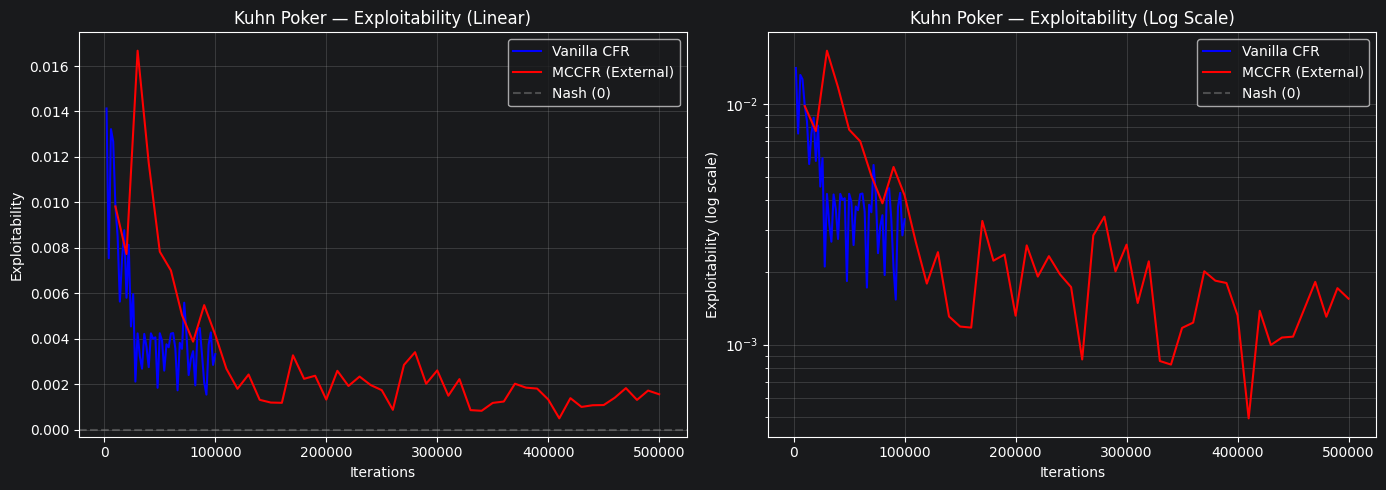

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.plot(kuhn_cfr_iters, kuhn_cfr_expl, 'b-', linewidth=1.5, label='Vanilla CFR')
    ax.plot(kuhn_mc_iters, kuhn_mc_expl, 'r-', linewidth=1.5, label='MCCFR (External)')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Nash (0)')
    ax.set_xlabel('Iterations')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

axes[0].set_ylabel('Exploitability')
axes[0].set_title('Kuhn Poker — Exploitability (Linear)')

axes[1].set_ylabel('Exploitability (log scale)')
axes[1].set_title('Kuhn Poker — Exploitability (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## Kuhn Poker — MCCFR Strategy vs Known Nash Equilibrium

In [6]:
kuhn_strategy = kuhn_mccfr.get_strategy()

nash_reference = {
    'J:':   [2/3, 1/3],
    'Q:':   [1.0, 0.0],
    'K:':   [0.0, 1.0],
    'J:P':  [2/3, 1/3],
    'Q:P':  [1.0, 0.0],
    'K:P':  [0.0, 1.0],
    'J:B':  [1.0, 0.0],
    'Q:B':  [2/3, 1/3],
    'K:B':  [0.0, 1.0],
    'J:PB': [1.0, 0.0],
    'Q:PB': [2/3, 1/3],
    'K:PB': [0.0, 1.0],
}

print(f"{'Info Set':<10} {'MCCFR P/F':>10} {'MCCFR B/C':>10} {'Nash P/F':>10} {'Nash B/C':>10}")
print('-' * 54)
for key in sorted(kuhn_strategy.keys()):
    s = kuhn_strategy[key]
    nash = nash_reference.get(key, [None, None])
    nash_str = [f"{v:.3f}" if v is not None else "?" for v in nash]
    print(f"{key:<10} {s[0]:>10.3f} {s[1]:>10.3f} {nash_str[0]:>10} {nash_str[1]:>10}")

Info Set    MCCFR P/F  MCCFR B/C   Nash P/F   Nash B/C
------------------------------------------------------
J:              0.666      0.334      0.667      0.333
J:B             1.000      0.000      1.000      0.000
J:P             0.667      0.333      0.667      0.333
J:PB            1.000      0.000      1.000      0.000
K:              0.002      0.998      0.000      1.000
K:B             0.000      1.000      0.000      1.000
K:P             0.000      1.000      0.000      1.000
K:PB            0.000      1.000      0.000      1.000
Q:              1.000      0.000      1.000      0.000
Q:B             0.670      0.330      0.667      0.333
Q:P             1.000      0.000      1.000      0.000
Q:PB            0.337      0.663      0.667      0.333


## Leduc Poker — CFR vs MCCFR

In [7]:
leduc_game = LeducPokerRules()

print("Training Leduc Poker — Vanilla CFR...")
leduc_cfr_iters, leduc_cfr_expl, leduc_cfr = train_with_checkpoints(
    CFR, leduc_game, total_iterations=100_000, num_checkpoints=50, label="CFR"
)
print(f"  Final exploitability: {leduc_cfr_expl[-1]:.8f}\n")

print("Training Leduc Poker — MCCFR (External Sampling)...")
leduc_mc_iters, leduc_mc_expl, leduc_mccfr = train_with_checkpoints(
    MCCFR, leduc_game, total_iterations=500_000, num_checkpoints=50, label="MCCFR"
)
print(f"  Final exploitability: {leduc_mc_expl[-1]:.8f}")

Training Leduc Poker — Vanilla CFR...
  [CFR] Iteration    20000  |  Exploitability: 0.059667
  [CFR] Iteration    40000  |  Exploitability: 0.058130
  [CFR] Iteration    60000  |  Exploitability: 0.037002
  [CFR] Iteration    80000  |  Exploitability: 0.033216
  [CFR] Iteration   100000  |  Exploitability: 0.027368
  Final exploitability: 0.02736800

Training Leduc Poker — MCCFR (External Sampling)...
  [MCCFR] Iteration   100000  |  Exploitability: 0.224583
  [MCCFR] Iteration   200000  |  Exploitability: 0.195595
  [MCCFR] Iteration   300000  |  Exploitability: 0.288986
  [MCCFR] Iteration   400000  |  Exploitability: 0.251295
  [MCCFR] Iteration   500000  |  Exploitability: 0.364712
  Final exploitability: 0.36471234


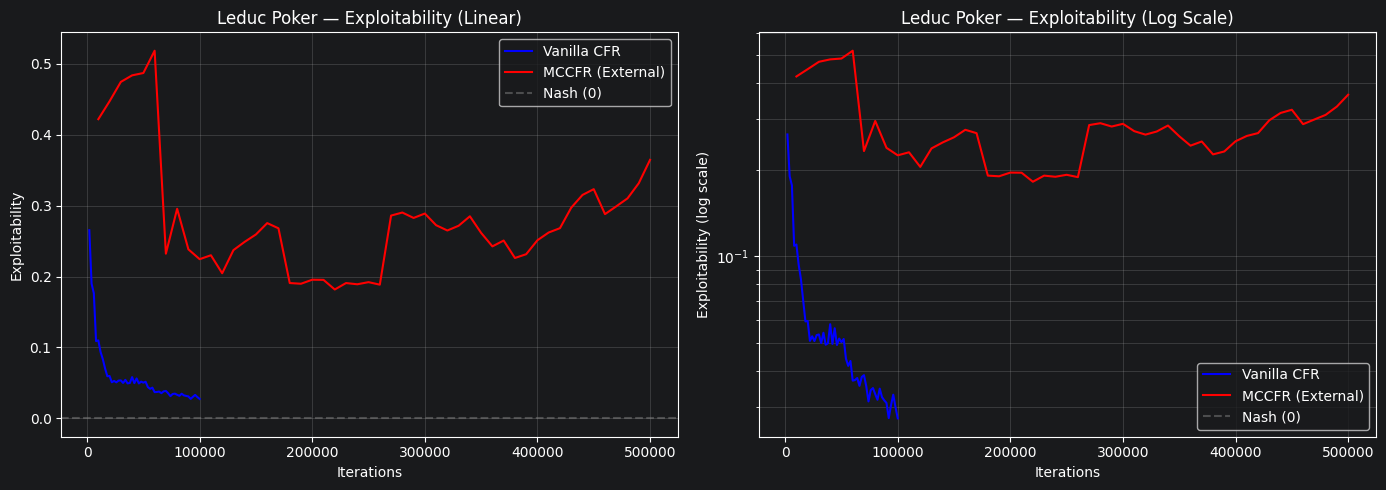

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.plot(leduc_cfr_iters, leduc_cfr_expl, 'b-', linewidth=1.5, label='Vanilla CFR')
    ax.plot(leduc_mc_iters, leduc_mc_expl, 'r-', linewidth=1.5, label='MCCFR (External)')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Nash (0)')
    ax.set_xlabel('Iterations')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

axes[0].set_ylabel('Exploitability')
axes[0].set_title('Leduc Poker — Exploitability (Linear)')

axes[1].set_ylabel('Exploitability (log scale)')
axes[1].set_title('Leduc Poker — Exploitability (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## Leduc Poker — MCCFR Sample Strategies

In [9]:
leduc_strategy = leduc_mccfr.get_strategy()

print("Round 1 — Opening strategies (history='')")
print(f"{'Info Set':<12} {'Pass':>8} {'Bet':>8}")
print('-' * 30)
for card_name in ['J', 'Q', 'K']:
    key = f"{card_name}:"
    if key in leduc_strategy:
        s = leduc_strategy[key]
        print(f"{key:<12} {s[0]:>8.3f} {s[1]:>8.3f}")

print("\nRound 2 — Opening strategies after check-check (history='PP//')")
print(f"{'Info Set':<12} {'Pass':>8} {'Bet':>8}")
print('-' * 30)
for hole in ['J', 'Q', 'K']:
    for board in ['J', 'Q', 'K']:
        key = f"{hole}|{board}:PP//"
        if key in leduc_strategy:
            s = leduc_strategy[key]
            print(f"{key:<12} {s[0]:>8.3f} {s[1]:>8.3f}")

Round 1 — Opening strategies (history='')
Info Set         Pass      Bet
------------------------------
J:              0.907    0.093
Q:              0.242    0.758
K:              0.247    0.753

Round 2 — Opening strategies after check-check (history='PP//')
Info Set         Pass      Bet
------------------------------
J|J:PP//        1.000    0.000
J|Q:PP//        0.918    0.082
J|K:PP//        0.935    0.065
Q|J:PP//        1.000    0.000
Q|Q:PP//        0.813    0.187
Q|K:PP//        0.623    0.377
K|J:PP//        1.000    0.000
K|Q:PP//        1.000    0.000
K|K:PP//        0.004    0.996


## Limit Hold'em — MCCFR Info Set Discovery

The game tree is too large for vanilla CFR to be practical. Here we track how many unique info sets MCCFR discovers over time — this shows how quickly the single-path sampling explores the game tree.

In [ ]:
def train_tracking_info_sets(algo_cls, game, total_iterations, num_checkpoints=40, label=""):
    """Train and record the number of unique info sets at each checkpoint."""
    algo = algo_cls(game)
    checkpoint_interval = max(1, total_iterations // num_checkpoints)

    iterations_list = []
    info_set_counts = []
    current_iter = 0

    for i in range(num_checkpoints):
        algo.train(checkpoint_interval)
        current_iter += checkpoint_interval

        count = len(algo.info_sets)
        iterations_list.append(current_iter)
        info_set_counts.append(count)

        if (i + 1) % 10 == 0:
            print(f"  [{label}] Iteration {current_iter:>8d}  |  Info sets: {count:,}")

    return iterations_list, info_set_counts, algo


print("Training Limit Poker — MCCFR (External Sampling)...")
limit_game = LimitPokerRules()
limit_mc_iters, limit_mc_info_sets, limit_mccfr = train_tracking_info_sets(
    MCCFR, limit_game, total_iterations=100_000, num_checkpoints=40, label="MCCFR"
)
print(f"\nFinal info sets discovered: {limit_mc_info_sets[-1]:,}")

Training Limit Poker — MCCFR (External Sampling)...


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(limit_mc_iters, limit_mc_info_sets, 'r-', linewidth=1.5)
ax.set_xlabel('Iterations')
ax.set_ylabel('Unique Info Sets')
ax.set_title('Limit Hold\'em MCCFR — Info Set Discovery Over Time')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Limit Poker — MCCFR Sample Strategies

In [ ]:
limit_strategy = limit_mccfr.get_strategy()

preflop_open = {k: v for k, v in limit_strategy.items() if ':' in k and k.split(':')[1] == ''}
print(f"Preflop opening — {len(preflop_open)} bucket info sets")
print(f"{'Info Set':<12} {'Pass':>8} {'Bet':>8}")
print('-' * 30)
for key in sorted(preflop_open.keys()):
    s = preflop_open[key]
    print(f"{key:<12} {s[0]:>8.3f} {s[1]:>8.3f}")

print(f"\nFlop opening after preflop PP (history='PP//')")
flop_open = {k: v for k, v in limit_strategy.items() if k.endswith(':PP//')}
print(f"{'Info Set':<16} {'Pass':>8} {'Bet':>8}")
print('-' * 34)
for key in sorted(flop_open.keys()):
    s = flop_open[key]
    print(f"{key:<16} {s[0]:>8.3f} {s[1]:>8.3f}")

## Summary — All Comparisons

Side-by-side convergence for Kuhn and Leduc (CFR vs MCCFR), plus info set discovery for Limit.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Kuhn comparison
axes[0].plot(kuhn_cfr_iters, kuhn_cfr_expl, 'b-', linewidth=1.5, label='Vanilla CFR')
axes[0].plot(kuhn_mc_iters, kuhn_mc_expl, 'r-', linewidth=1.5, label='MCCFR')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Exploitability (log)')
axes[0].set_title('Kuhn Poker')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3, which='both')

# Leduc comparison
axes[1].plot(leduc_cfr_iters, leduc_cfr_expl, 'b-', linewidth=1.5, label='Vanilla CFR')
axes[1].plot(leduc_mc_iters, leduc_mc_expl, 'r-', linewidth=1.5, label='MCCFR')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Exploitability (log)')
axes[1].set_title('Leduc Poker')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

# Limit — info set discovery
axes[2].plot(limit_mc_iters, limit_mc_info_sets, 'r-', linewidth=1.5, label='MCCFR')
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('Unique Info Sets')
axes[2].set_title('Limit Hold\'em — Info Sets')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('CFR vs MCCFR (External Sampling) — Convergence & Discovery', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Convergence Rate Analysis

Fit log-log slopes for both algorithms. Vanilla CFR converges at O(1/sqrt(T)); external sampling MCCFR has lower variance per iteration than outcome sampling since the traverser enumerates all actions.

In [ ]:
for name, datasets in [("Kuhn", [(kuhn_cfr_iters, kuhn_cfr_expl, "CFR"),
                                   (kuhn_mc_iters, kuhn_mc_expl, "MCCFR")]),
                       ("Leduc", [(leduc_cfr_iters, leduc_cfr_expl, "CFR"),
                                   (leduc_mc_iters, leduc_mc_expl, "MCCFR")])]:
    print(f"{name} Poker:")
    for iters, expl, algo_name in datasets:
        half = len(iters) // 2
        log_iters = np.log(iters[half:])
        log_expl = np.log(np.maximum(expl[half:], 1e-12))
        coeffs = np.polyfit(log_iters, log_expl, 1)
        print(f"  {algo_name:<8} log-log slope: {coeffs[0]:>7.3f}  (expected ~-0.5 for vanilla CFR)")
    print()